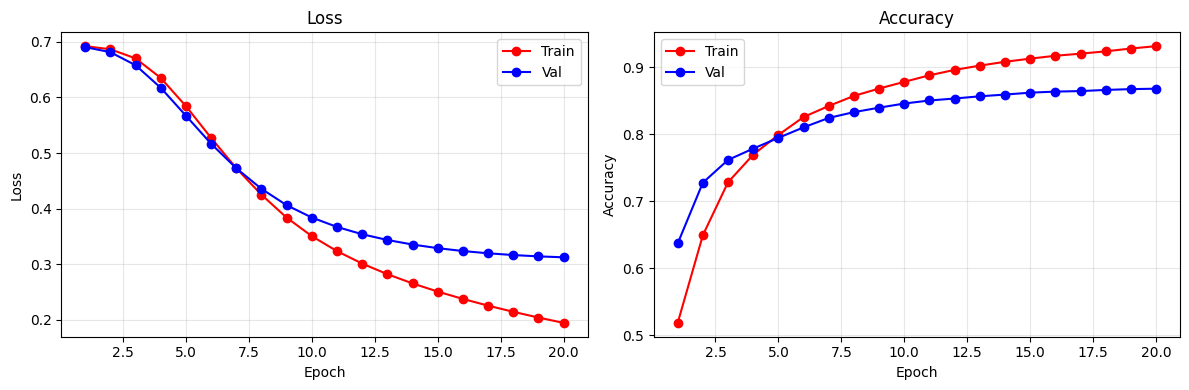

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9318 - loss: 0.1981 - val_accuracy: 0.8678 - val_loss: 0.3126

Test Accuracy: 0.8678


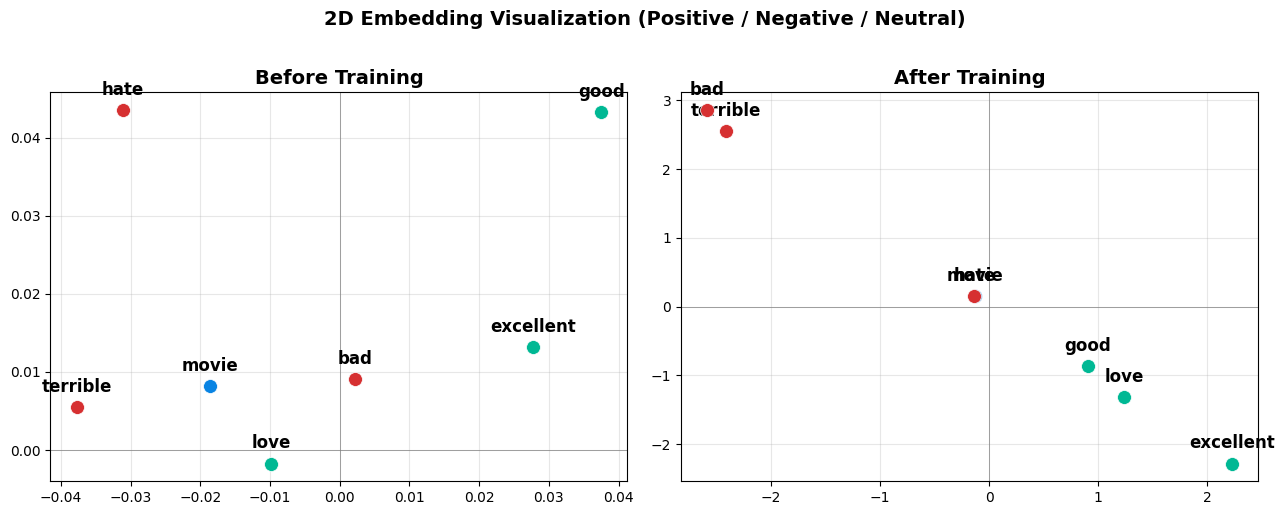

In [2]:
# ==============================
# Week 7 : IMDB Embedding Visualization
# Before vs After Training
# ==============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback

tf.random.set_seed(42)
np.random.seed(42)

VOCAB_SIZE = 10000
MAX_LEN = 200
NUM_SAMPLES = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
X_train, y_train = X_train[:NUM_SAMPLES], y_train[:NUM_SAMPLES]
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

class LivePlot(Callback):
    def on_train_begin(self, logs=None):
        self.h = {k: [] for k in ['loss','val_loss','accuracy','val_accuracy']}
    def on_epoch_end(self, epoch, logs=None):
        for k in self.h: self.h[k].append(logs[k])
        ep = range(1, epoch + 2)
        clear_output(wait=True)
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
        a1.plot(ep, self.h['loss'], 'r-o', label='Train'); a1.plot(ep, self.h['val_loss'], 'b-o', label='Val')
        a1.set(title='Loss', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid(True, alpha=.3)
        a2.plot(ep, self.h['accuracy'], 'r-o', label='Train'); a2.plot(ep, self.h['val_accuracy'], 'b-o', label='Val')
        a2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy'); a2.legend(); a2.grid(True, alpha=.3)
        fig.tight_layout(); display(fig); plt.close(fig)

# --- Model (dim=2 for visualization) ---
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, 2),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, MAX_LEN))
initial_weights = model.layers[0].get_weights()[0].copy()

model.fit(X_train, y_train, epochs=20, batch_size=128,
          validation_data=(X_test, y_test), callbacks=[LivePlot()])

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f}")

trained_weights = model.layers[0].get_weights()[0]

# --- Embedding Before vs After ---
word_index = imdb.get_word_index()
selected_words = ["good", "bad", "excellent", "terrible", "movie", "love", "hate"]
colors_map = {'good':'#00b894','bad':'#d63031','excellent':'#00b894','terrible':'#d63031',
              'movie':'#0984e3','love':'#00b894','hate':'#d63031'}
indices, valid_words = [], []
for w in selected_words:
    if w in word_index:
        idx = word_index[w] + 3
        if idx < VOCAB_SIZE:
            indices.append(idx)
            valid_words.append(w)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for i, w in zip(indices, valid_words):
    c = colors_map.get(w, '#636e72')
    x, y = initial_weights[i]
    ax1.scatter(x, y, c=c, s=100, zorder=5, edgecolors='white', linewidth=0.5)
    ax1.annotate(w, (x, y), fontsize=12, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')
ax1.set_title('Before Training', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3); ax1.axhline(0, c='grey', lw=0.5); ax1.axvline(0, c='grey', lw=0.5)

for i, w in zip(indices, valid_words):
    c = colors_map.get(w, '#636e72')
    x, y = trained_weights[i]
    ax2.scatter(x, y, c=c, s=100, zorder=5, edgecolors='white', linewidth=0.5)
    ax2.annotate(w, (x, y), fontsize=12, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')
ax2.set_title('After Training', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3); ax2.axhline(0, c='grey', lw=0.5); ax2.axvline(0, c='grey', lw=0.5)

fig.suptitle('2D Embedding Visualization (Positive / Negative / Neutral)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); display(fig); plt.close(fig)